In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
prices = pd.read_csv("prices.txt", sep='\\s+')

In [4]:
prices.head(5)

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56


In [5]:
prices.describe()

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,100.899040,95.080140,91.058820,114.758700,92.116180,17.82138,22.039700,65.876740,70.013320,17.659780,...,43.166940,26.530120,23.187960,11.61532,58.557660,43.060320,31.836200,42.57322,16.458080,32.663180
std,6.481024,23.271136,12.060809,22.755559,15.711289,3.51958,5.823085,6.198557,13.504342,4.048989,...,5.054041,1.760292,2.353774,1.02718,13.448617,8.696074,4.883482,8.77605,3.173302,6.772426
min,84.850000,52.500000,73.130000,71.590000,61.580000,11.55000,12.610000,53.610000,42.790000,10.370000,...,33.620000,23.820000,17.940000,9.44000,33.730000,30.840000,22.520000,31.25000,8.200000,17.110000
25%,97.525000,72.562500,81.487500,98.315000,79.190000,15.54750,16.850000,60.847500,61.355000,14.420000,...,38.810000,25.277500,21.475000,10.82750,50.255000,34.085000,28.222500,35.22500,14.617500,28.502500
50%,101.440000,101.470000,87.980000,115.275000,94.340000,16.49000,21.715000,65.615000,71.330000,18.210000,...,44.405000,26.025000,23.450000,11.54000,56.745000,43.580000,31.350000,39.25500,17.310000,33.490000
75%,105.687500,115.772500,97.837500,130.782500,105.645000,20.93250,26.777500,69.625000,80.442500,20.262500,...,46.625000,27.485000,25.130000,12.31250,71.435000,48.870000,35.820000,49.13000,18.880000,37.930000
max,115.420000,133.520000,122.860000,166.260000,123.030000,26.23000,34.290000,80.980000,96.600000,27.350000,...,56.180000,32.370000,28.250000,14.10000,85.840000,60.990000,43.690000,66.43000,22.410000,46.420000


In [6]:
prices.shape

(500, 51)

Compute returns. We choose log returns over simple returns for two reasons:
1. They add across time. Log returns over a week sum to the weekly log return; simple returns must be compounded (multiplied). Sums are far easier to do statistics on.
2. They are close to symmetric. A +10% then -10% simple return leaves you down 1%, an annoying asymmetry; in log space +x then -x is exactly zero.
3. For small daily moves the two are nearly identical (ln(1+r) ≈ r), so you lose almost nothing and gain the algebra.

In [7]:
log_ret = np.log(prices / prices.shift(1)).dropna()
print(log_ret.shape)
print(log_ret.head(3))

(499, 51)
       ALGO      AENO      LSST      SRNA      ELLT      AMRP      OTCS  \
1 -0.015215 -0.031120  0.008594 -0.007628 -0.021757 -0.044488 -0.008895   
2 -0.006724 -0.002127 -0.020821 -0.003083 -0.018175 -0.027932  0.009576   
3  0.001940 -0.003912  0.034350  0.002707  0.031003  0.007270 -0.017858   

       HETT      HUXZ      DUCT  ...      BLBT      BENI      ITPA      HTRK  \
1 -0.016338 -0.045006 -0.025175  ...  0.009528 -0.003714 -0.022026 -0.008322   
2 -0.005333  0.015639  0.000000  ...  0.009438 -0.000620 -0.010374 -0.007456   
3 -0.016524  0.007606  0.008806  ... -0.010576 -0.000931  0.000000 -0.039108   

       NGTE      ILVX      FCSG      FARS      MHRM      EAFC  
1 -0.057460 -0.028645 -0.036718 -0.027006 -0.013930 -0.017906  
2  0.016361 -0.026242 -0.045998 -0.007295 -0.057265  0.022774  
3  0.021729  0.003560 -0.027267 -0.021892  0.003826  0.022267  

[3 rows x 51 columns]


## Gaussian Test

Is the world Gaussian?

The Gaussian (or normal) distribution is the classic bell curve. It says: most days cluster near the average, and the further you go from average, the rarer days get, at a very precisely defined rate. That rate is the whole point.

The "tails" are those extreme ends of the distribution, the rare big moves. A distribution is fat-tailed when those extremes happen far more often than the Gaussian rate above. Real financial markets are famously fat-tailed: 5-sigma days that "should" never happen show up every few years (1987, 2008, 2020).

A Gaussian is completely described by just two numbers: its mean and its variance. There is nothing else to know. And a deep result is that for two jointly-Gaussian variables, all their dependence is captured by their correlation, a single linear number. There is no hidden nonlinear relationship to discover, because Gaussians have none by construction.

Since linear tools are used to capture linear relationshipa and ML is used to capture the non-linearity, this means:
- If the world is Gaussian, we can confidently use simple, robust linear methods and deliberately refuse to reach for ML.
- If the answer is fat-tailed, we'd have to add tail-aware risk controls and consider that nonlinear structure might exist.

We measure this with excess kurtosis: `mean(((x-mu)/sigma)^4) - 3`.

- excess kurtosis = 0   -> tails like a Gaussian (extremes as rare as the bell curve says)
- excess kurtosis > 0   -> fatter tails (crashes and spikes more common than Gaussian)
- excess kurtosis < 0   -> thinner tails (extremes rarer; data hugs a bounded range)     

In [8]:
log_ret.kurt().mean()

np.float64(-0.02642138929856778)

Skew measures asymmetry: is the distribution lopsided, with one tail longer than the other? It's the third standardised moment, the sibling of kurtosis but with a cube instead of a fourth power: `mean(((x-mu)/sigma)^3)`

skew > 0  (positive / "right-skewed"):
- Long tail on the RIGHT. Most days are small and slightly negative, with occasional large POSITIVE moves. For returns: rare big gains.
- Mean sits above the median.

skew < 0  (negative / "left-skewed"):
- Long tail on the LEFT. Most days small and slightly positive, with occasional large NEGATIVE moves. For returns: rare big losses (crash-like).
- Mean sits below the median.

skew = 0:
- Symmetric. Up-moves and down-moves are mirror images. This is what a Gaussian has.

In [9]:
log_ret.skew().mean()

np.float64(0.0016750788857572939)

QQ Plot - Plots actual vs theoretical normal. 

1. Take your k-th smallest return. Its rank gives it a percentile, say it's the point sitting at the 97.5th percentile of your data.
2. Ask the Normal: what value do you put at the 97.5th percentile? Answer: +1.96 (times your sigma).
3. Plot your actual value against that +1.96.

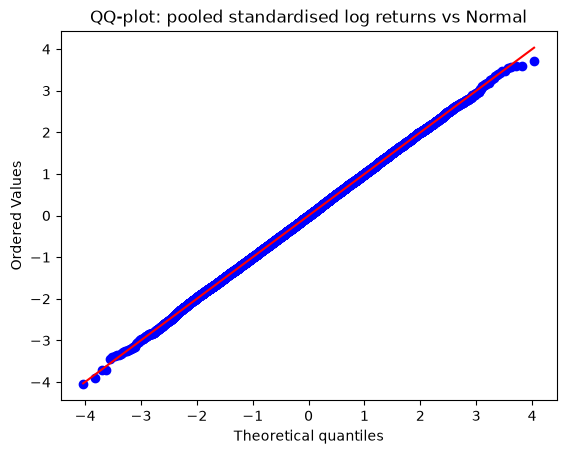

In [10]:
z = (log_ret - log_ret.mean()) / log_ret.std()   # standardise each column
zflat = z.values.flatten()                         # all 51 x 499 points in one array

stats.probplot(zflat, dist="norm", plot=plt)
plt.title("QQ-plot: pooled standardised log returns vs Normal")
plt.show()

## Volatility Constant Test

Is volatility constant or does it cluster? We just showed returns are Gaussian overall. But that's a statement about the whole 499-day pile at once. It does not tell us whether the size of moves is steady through time or comes in bursts. In real markets, volatility clusters: a big move tends to be followed by more big moves.

So separate two different questions:
- Direction (sign) predictability = drift or momentum. "Does an up-day tend to be followed by an up-day?"
- Magnitude predictability = volatility clustering. "Does a big day (either direction) tend to be followed by a big day?"

We square the returns so that we ignore the direction, then we ask whether the size series is autocorrelated.

Autocorrelation: The correlation of a series with a lagged copy of itself. Autocorrelation of $r^2$ (daily return squared) at lag 1 asks exactly "does today's move-size correlate with tomorrow's?".
- autocorr of $r^2$ at lag 1 ≈ 0        -> volatility is constant (no clustering)
- autocorr of $r^2$ at lag 1  > 0        -> clustering (big follows big) -> would need a GARCH vol model

If there's clustering, one fixed sigma per instrument is wrong and we'd need a time-varying volatility model (GARCH) to size positions. If there's none, each instrument's risk is a single stable number. 

In [11]:
sq = log_ret**2
ac1 = sq.apply(lambda col: col.autocorr(lag=1))
print("lag-1 autocorr of squared returns: mean %.3f, range [%.3f, %.3f]"
      % (ac1.mean(), ac1.min(), ac1.max()))

lag-1 autocorr of squared returns: mean -0.006, range [-0.099, 0.151]


Mean is -0.006, no clustering. 

## Risk Unit

In [12]:
daily_vol = log_ret.std()
annual_vol = daily_vol * np.sqrt(250)

print("daily vol:  mean %.4f, range [%.4f, %.4f]" % (daily_vol.mean(), daily_vol.min(), daily_vol.max()))
print("annual vol: mean %.3f, range [%.3f, %.3f]" % (annual_vol.mean(), annual_vol.min(), annual_vol.max()))

daily vol:  mean 0.0220, range [0.0099, 0.0409]
annual vol: mean 0.348, range [0.157, 0.647]


We are always scored on days you have never seen. So a number measured on our 500 days is worthless unless it reflects a stable property of the generator, something that will still be true on days 501 onward, rather than a fluke of this particular sample.

How do you test that when you don't have the future? You simulate the situation. You split the data in half, days 1-250 and days 250-499, treat the first half as "data we have" and the second as "the unseen future", measure the parameter separately on each, and ask: does the first half predict the second?

For volatility, concretely: estimate each instrument's vol on the first 250 days (51 numbers) and again on the last ~250 days (another 51 numbers). Now correlate those two sets of 51 numbers across instruments.

split-half vol correlation: 0.982


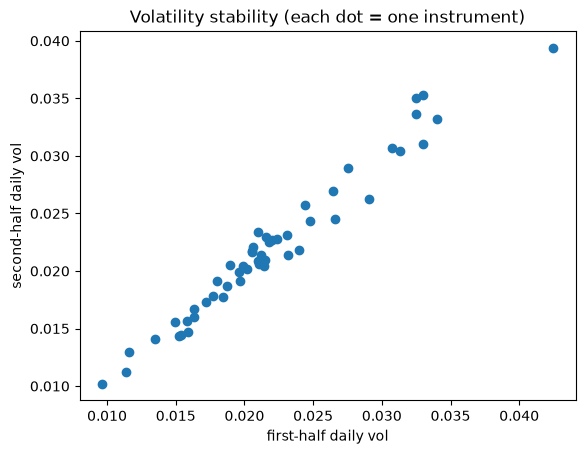

In [13]:
half = len(log_ret) // 2
vol_first  = log_ret.iloc[:half].std()
vol_second = log_ret.iloc[half:].std()

corr = np.corrcoef(vol_first, vol_second)[0, 1]
print("split-half vol correlation: %.3f" % corr)

plt.scatter(vol_first, vol_second)
plt.xlabel("first-half daily vol"); plt.ylabel("second-half daily vol")
plt.title("Volatility stability (each dot = one instrument)")
plt.show()

The instrument that's wildest early is wildest late; the ranking barely moves. So volatility is a genuine, persistent fingerprint of each instrument, not a sample fluke. We can measure it on data we have and trust it on data we don't.

Summary: Returns are Gaussian, symmetric, thin-tailed, with constant and highly stable per-instrument volatility. Linear tools are sufficient. 

In [14]:
corr_matrix = log_ret.corr()

# average of the off-diagonal entries (exclude each instrument's correlation with itself = 1)
mask = ~np.eye(len(corr_matrix), dtype=bool)
avg_corr = corr_matrix.values[mask].mean()
print("average pairwise correlation: %.3f" % avg_corr)

average pairwise correlation: 0.200
